# 

Test of trigger

In [1]:
files = [ "/data/HD6/users/brownd/ntp.mu2e.ensembleMDS1eMix1BBTriggered.MDC2020ai_perfect_v1_3.root:EventNtuple/ntuple" ]
#files = [ "/data/HD6/users/brownd/ENfrom_dig.root:EventNtupleTTMCApr//ntuple" ]

In [2]:
import os
import uproot 
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#import tensorflow as tf
from pathlib import Path
#from skspatial.objects import Vector
print("Hello world")

Hello world


In [3]:
mid_px = []
mid_py = []
mid_pz = []
for batch,rep in uproot.iterate(files,filter_name="/trk|trksegs|trkmcsim/i",report=True):
    print("Fields available in 'trksegs':", ak.fields(batch["trksegs"]))
    trksegs = batch["trksegs"][:,0]
    down_mid = (trksegs["sid"] == 1) & (trksegs['mom']['fCoordinates']['fZ'] > 0) # downstream mid tracker
    has_down_mid = ak.sum(down_mid,axis=1) > 0
    mid_px.extend(ak.flatten(trksegs[has_down_mid][down_mid]['mom']['fCoordinates']['fX']))
    mid_py.extend(ak.flatten(trksegs[has_down_mid][down_mid]['mom']['fCoordinates']['fY']))
    mid_pz.extend(ak.flatten(trksegs[has_down_mid][down_mid]['mom']['fCoordinates']['fZ']))
    
mid_mom2 = np.square(mid_px) + np.square(mid_py) + np.square(mid_pz)
mid_mom = np.sqrt(mid_mom2)
print("trksegs mid momentum ",len(mid_mom),mid_mom[:10])

Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']
Fields available in 'trksegs': ['mom', 'pos', 'time', 'dmom', 'momerr', 'inbounds', 'gap', 'early', 'late', 'sid', 'sindex']


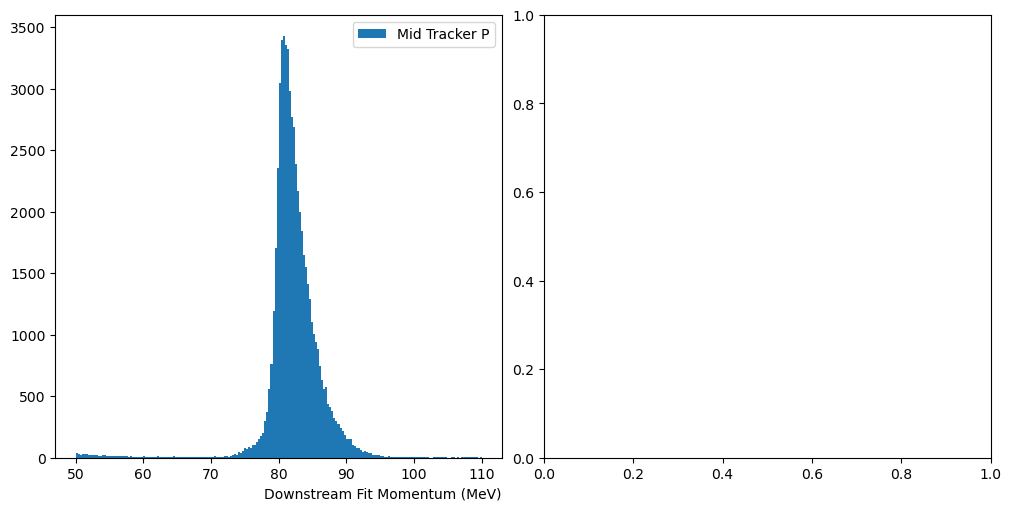

In [4]:
fig, (ax0, ax1 )  = plt.subplots(1,2,layout='constrained', figsize=(10,5))
ax0.hist(mid_mom,label="Mid Tracker P",bins=200,range=(50,110))
ax0.set_xlabel("Downstream Fit Momentum (MeV)",loc='right')
ax0.legend()